## **Employee Salary Prediction using Exploratory Data Analysis and Machine Learning**

---


**Problem Statement**

Employee salaries are influenced by factors such as age, experience, education, job title, department, and location. This project aims to analyze these factors using Exploratory Data Analysis (EDA) and build a Machine Learning model to predict employee salaries accurately.


**Objective**

* Understand the employee dataset
* Clean and preprocess the data
* Perform detailed Exploratory Data Analysis (EDA)
* Identify the key factors affecting employee salary
* Build a Machine Learning model for salary prediction
* Evaluate the model performance


## Dataset Overview

| Column Name      | Description                                                                      |
| ---------------- | -------------------------------------------------------------------------------- |
| Employee_ID      | Unique identification number assigned to each employee.                          |
| Name             | Name of the employee.                                                            |
| Age              | Age of the employee in years.                                                    |
| Gender           | Gender of the employee (Male/Female).                                            |
| Department       | Department in which the employee works (e.g., HR, Engineering, Sales).           |
| Job_Title        | Designation or job role of the employee.                                         |
| Experience_Years | Total years of work experience of the employee.                                  |
| Education_Level  | Highest educational qualification of the employee (Bachelor, Master, PhD, etc.). |
| Location         | City where the employee is working.                                              |
| Salary           | Annual salary of the employee (Target Variable).                                 |


**1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load Dataset**

In [ ]:
df=pd.read_csv("Employee_Data.csv")

df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


**3. Dataset Information**

In [ ]:
df.shape

df.columns

df.info()

df.describe()

print("Lenght: ",len(df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
Lenght:  10000


**Insight:**

The dataset contains 10,000 employee records and 10 features. All columns have 10,000 non-null values, indicating that the dataset is complete. It consists of 4 integer (int64) columns and 6 object (categorical) columns, making it suitable for both Exploratory Data Analysis (EDA) and Machine Learning.



**4. Missing Values**

In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Name,0
Age,0
Gender,0
Department,0
Job_Title,0
Experience_Years,0
Education_Level,0
Location,0
Salary,0


 **Insight:**

No missing values were found in the dataset.

**5. Duplicate Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Insight:**

No duplicate records were found in the dataset, indicating that each employee entry is unique.

## **6. Univariate Analysis**

**Age Distribution**

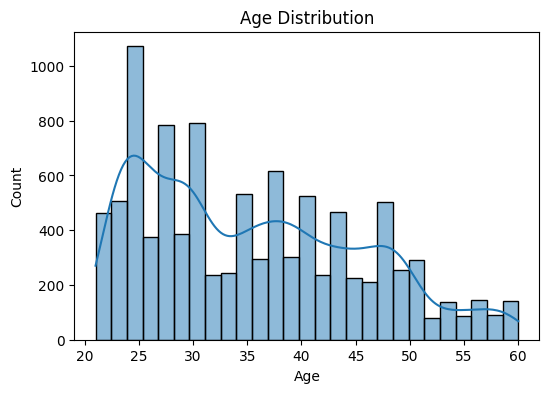

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

**Experience Years Distribution**

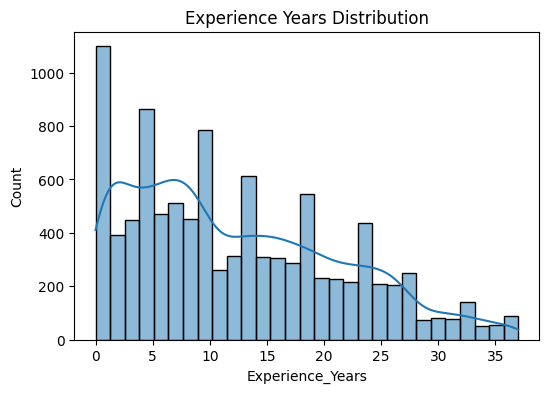

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Experience_Years"], kde=True)
plt.title("Experience Years Distribution")
plt.show()

**Salary Distribution**

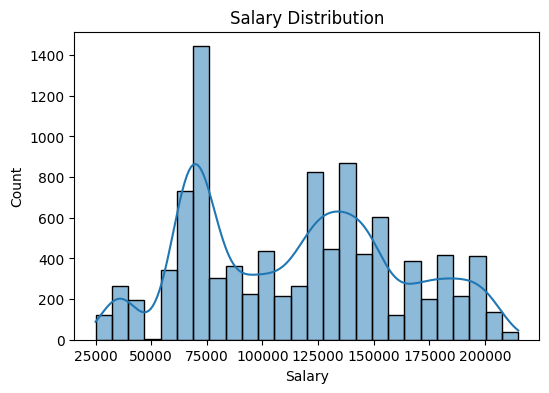

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

## **7. Categorical Analysis**

**Gender**

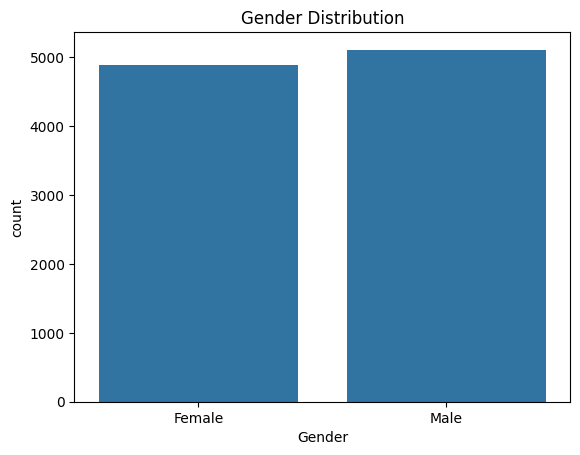

In [ ]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

**Department**

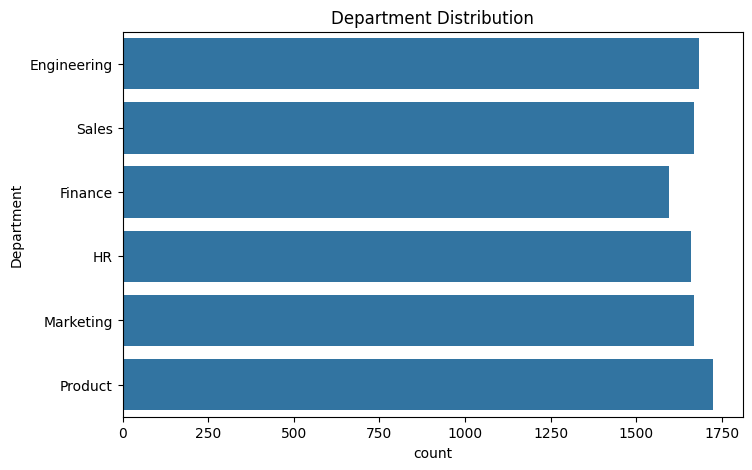

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y="Department", data=df)
plt.title("Department Distribution")
plt.show()

**Education Level**

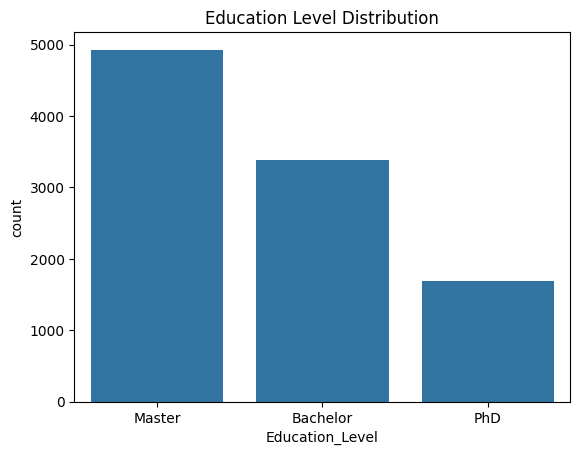

In [ ]:
sns.countplot(x="Education_Level", data=df)
plt.title("Education Level Distribution")
plt.show()

**Job Title**

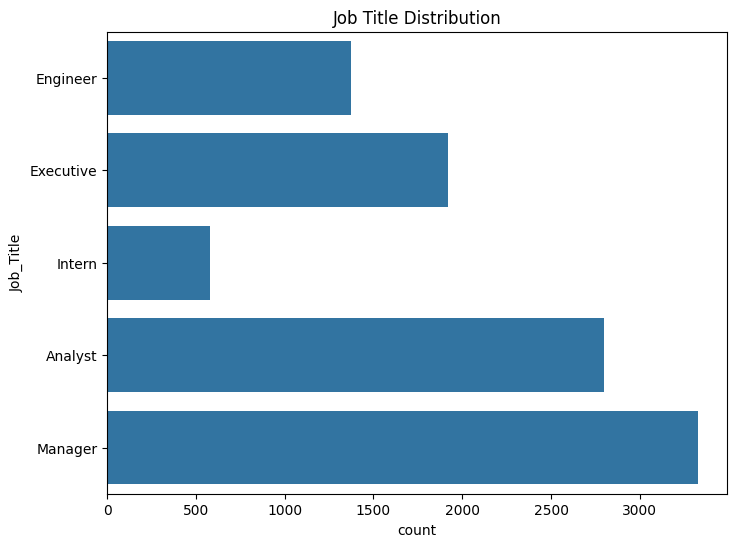

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(y="Job_Title", data=df)
plt.title("Job Title Distribution")
plt.show()

**Location**

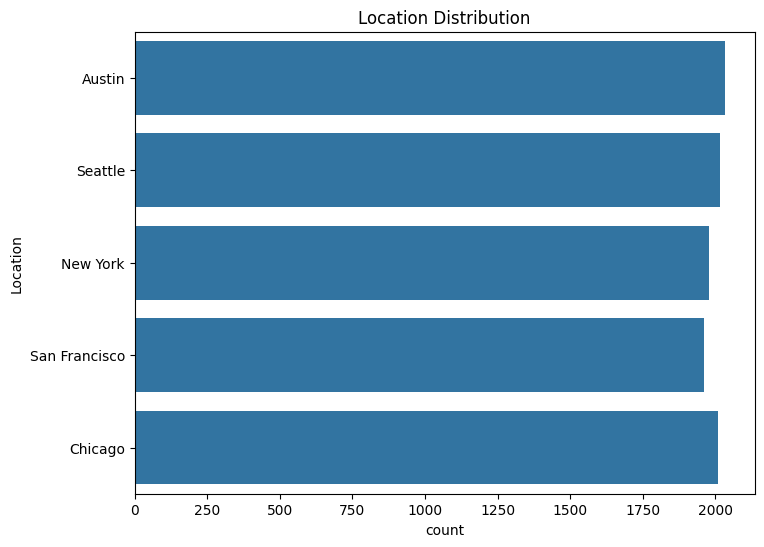

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(y="Location", data=df)
plt.title("Location Distribution")
plt.show()

## **8. Bivariate Analysis**

**Age vs Salary**

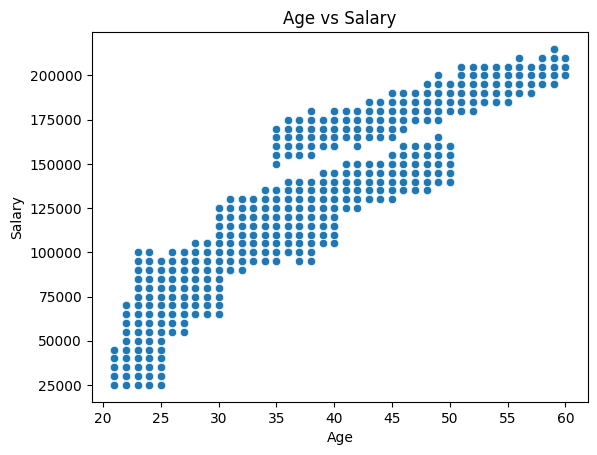

In [ ]:
sns.scatterplot(x="Age", y="Salary", data=df)
plt.title("Age vs Salary")
plt.show()

**Experience vs Salary**

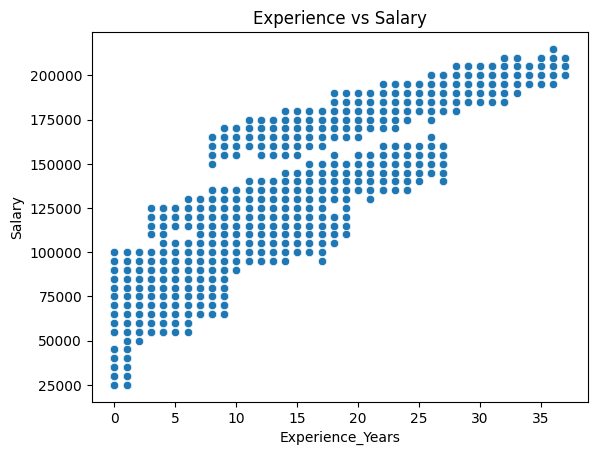

In [ ]:
sns.scatterplot(x="Experience_Years", y="Salary", data=df)
plt.title("Experience vs Salary")
plt.show()

**Gender vs Salary**

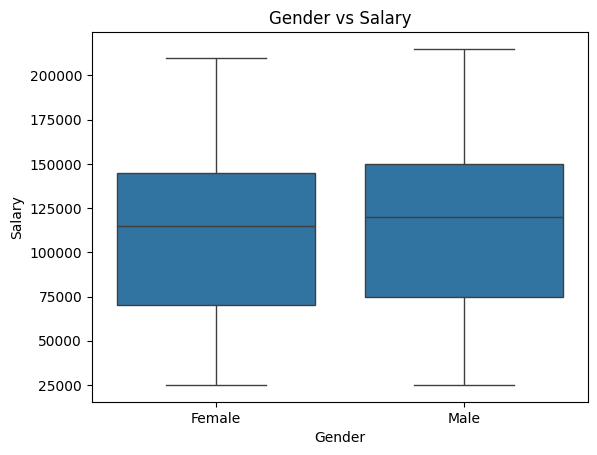

In [ ]:
sns.boxplot(x="Gender", y="Salary", data=df)
plt.title("Gender vs Salary")
plt.show()

**Department vs Salary**

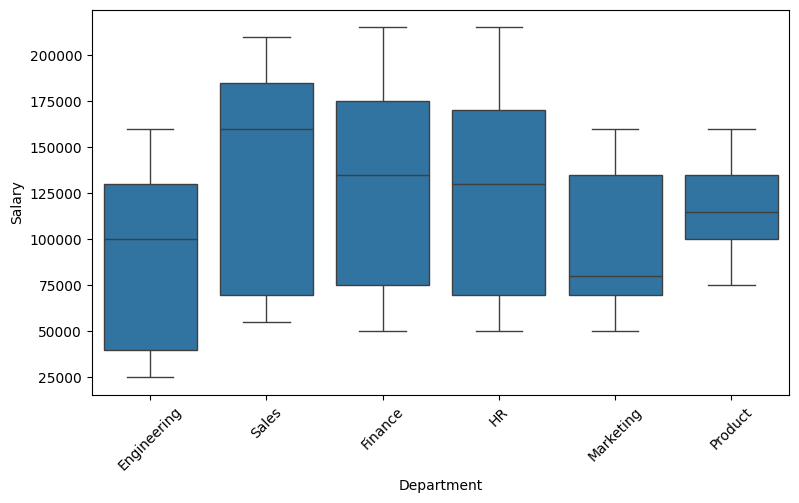

In [ ]:
plt.figure(figsize=(9,5))
sns.boxplot(x="Department", y="Salary", data=df)
plt.xticks(rotation=45)
plt.show()

**Education Level vs Salary**

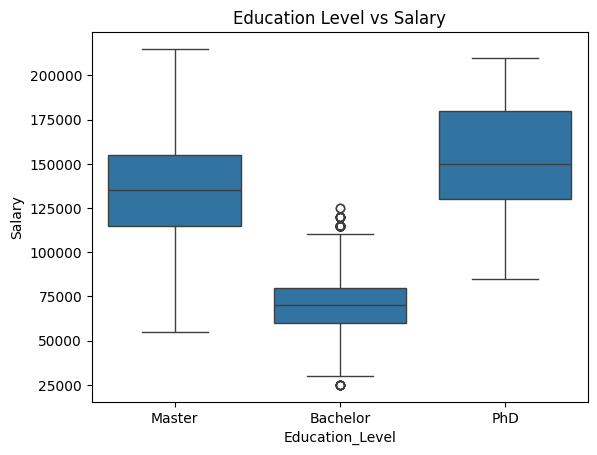

In [ ]:
sns.boxplot(x="Education_Level", y="Salary", data=df)
plt.title("Education Level vs Salary")
plt.show()

**9. Correlation Heatmap**

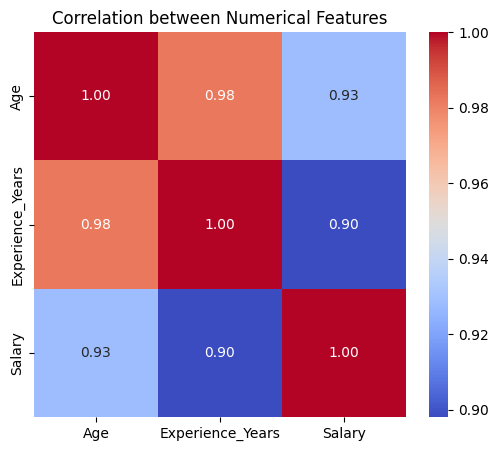

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(df[['Age','Experience_Years','Salary']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation between Numerical Features")
plt.show()

**10. Outliers Detection**

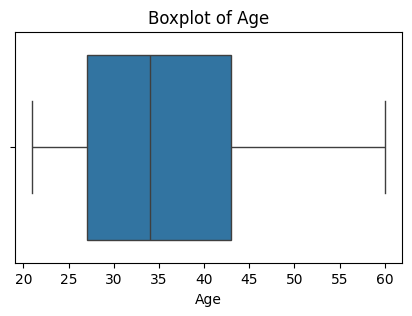

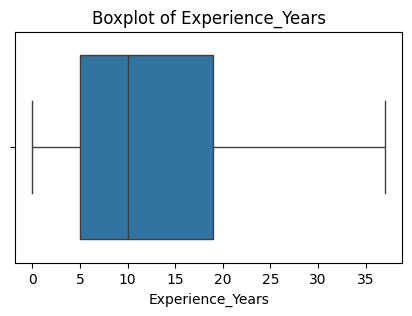

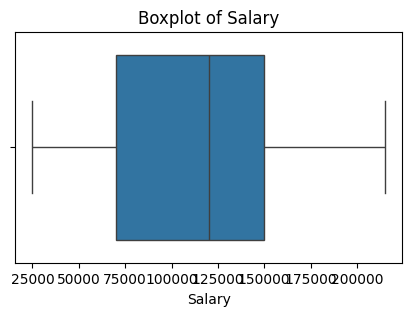

In [ ]:
num_cols = ['Age', 'Experience_Years', 'Salary']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**11. Feature Importance**

            Feature  Importance
0               Age    0.819562
3         Job_Title    0.150406
4  Experience_Years    0.026061
6          Location    0.001710
2        Department    0.001279
1            Gender    0.000750
5   Education_Level    0.000233


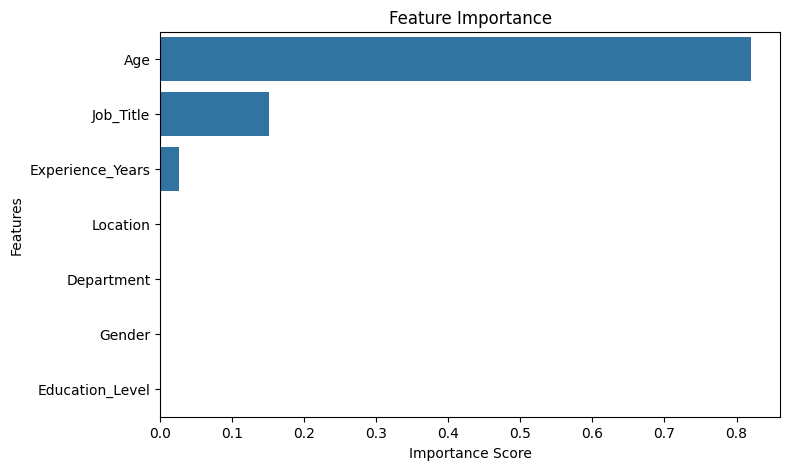

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# Create a copy of the dataset
df_encoded = df.copy()

# Encode all categorical columns
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features and Target
X = df_encoded.drop(['Employee_ID', 'Name', 'Salary'], axis=1)
y = df_encoded['Salary']

# Train Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Create Feature Importance DataFrame
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort values
importance = importance.sort_values(by='Importance', ascending=False)

# Display Feature Importance
print(importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

**Insight:**

he Feature Importance analysis shows that Age has the highest impact on salary prediction with an importance score of around 0.8, indicating it is the most dominant factor in the dataset. This is followed by Job_Title and Experience_Years, which also significantly influence salary. Other features contribute comparatively less to the model prediction.

## **Final EDA Summary**

The dataset contains 10,000 employee records with 10 features, including both numerical and categorical variables. The data is clean with no missing or duplicate values, making it suitable for analysis. Most employees fall within the 20–40 age range and have 1–15 years of experience, indicating a relatively young workforce.

Correlation and feature importance analysis indicate that Age, Job_Title, and Experience_Years are the most influential factors affecting salary, while other features have relatively lower impact.

## **Machine Learning Model Development**

Encode

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

Split Features and Target

In [ ]:
X = df_encoded.drop(['Employee_ID', 'Name', 'Salary'], axis=1)
y = df_encoded['Salary']

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model 1: Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R2 Score:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

R2 Score: 0.8973591437624894
MAE: 11534.88404167907
RMSE: 14708.236865707551


**Model 2: Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

R2 Score: 0.9884787700695461
MAE: 3922.236848846781
RMSE: 4927.764041192794


**Compare Both Models**

In [ ]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

print(results)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  11534.884042  14708.236866  0.897359
1      Random Forest   3922.236849   4927.764041  0.988479


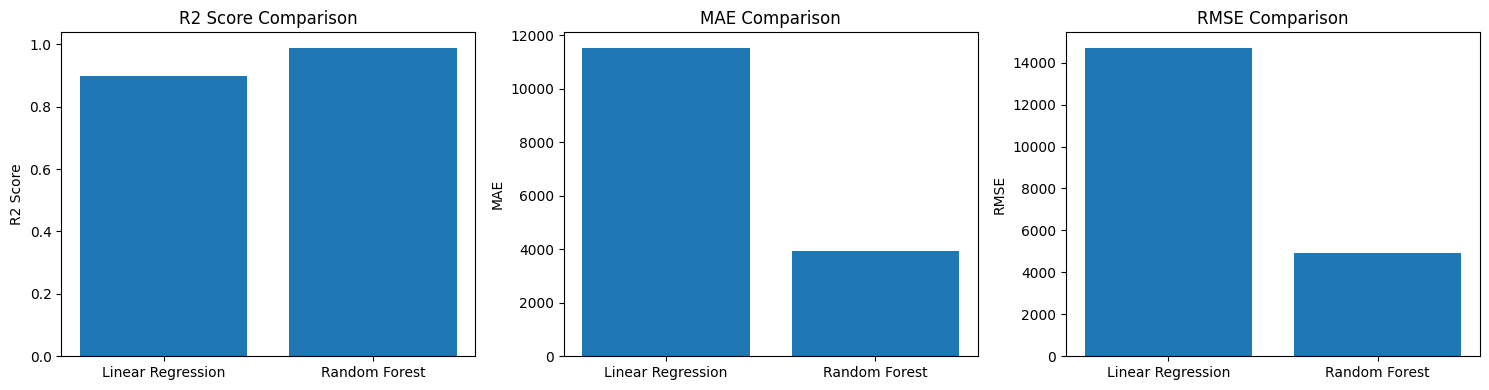

In [ ]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']

r2_scores = [lr_r2, rf_r2]
mae_values = [lr_mae, rf_mae]
rmse_values = [lr_rmse, rf_rmse]

plt.figure(figsize=(15,4))

# ---------------- R2 Score ----------------
plt.subplot(1,3,1)
plt.bar(models, r2_scores)
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")

# ---------------- MAE ----------------
plt.subplot(1,3,2)
plt.bar(models, mae_values)
plt.title("MAE Comparison")
plt.ylabel("MAE")

# ---------------- RMSE ----------------
plt.subplot(1,3,3)
plt.bar(models, rmse_values)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

## **Machine Learning Summary**

wo regression models were trained to predict employee salary: Linear Regression and Random Forest Regressor. After evaluation, it was observed that the Random Forest model outperforms Linear Regression across all metrics.

The Random Forest model achieved a higher R² score (≈ 0.99) compared to Linear Regression (≈ 0.90), indicating that it explains almost all variance in the target variable. Additionally, Random Forest shows significantly lower MAE and RMSE values, which means its predictions are more accurate and closer to actual salary values.